## Name : Pranali Nandu Ushire

## Roll No : DS24MS22

## Class : MSC(DS)

# Project Description

This project aims to develop a predictive model that estimates the selling price of used cars based on various features such as brand, manufacturing year, kilometers driven, fuel type, and more. Using regression techniques, particularly linear regression and potentially other advanced models (e.g. Random Forest,KNN) the goal is to understand the key factors influencing car prices and build a robust model that can predict prices accurately.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df= pd.read_csv("https://raw.githubusercontent.com/rahulinchal/SPPU/refs/heads/main/Data/Car_Price_Prediction.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
df.shape

(4340, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,4340.0,2013.090783,4.215344,1992.0,2011.00,2014.0,2016.0,2020.0
selling_price,4340.0,504127.311751,578548.736139,20000.0,208749.75,350000.0,600000.0,8900000.0
km_driven,4340.0,66215.777419,46644.102194,1.0,35000.00,60000.0,90000.0,806599.0


 # Data cleaning

In [6]:
df.isnull().sum()

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [9]:
df.dtypes

name             object
year              int64
selling_price     int64
km_driven         int64
fuel             object
seller_type      object
transmission     object
owner            object
dtype: object

In [10]:
print(df.fuel.value_counts())
print(df.seller_type.value_counts())
print(df.transmission.value_counts())

fuel
Diesel      2153
Petrol      2123
CNG           40
LPG           23
Electric       1
Name: count, dtype: int64
seller_type
Individual          3244
Dealer               994
Trustmark Dealer     102
Name: count, dtype: int64
transmission
Manual       3892
Automatic     448
Name: count, dtype: int64


In [11]:
df['car_brand'] = df['name'].str.split(' ')

In [12]:
df['car_brand'] = df['car_brand'].apply(lambda x: x[0])

In [13]:
df = df.drop(columns=['name'])
df.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'car_brand'],
      dtype='object')

In [14]:
for i in df.select_dtypes('object').columns:
    print(i,"\n",df[i].unique(),"\n")

fuel 
 ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric'] 

seller_type 
 ['Individual' 'Dealer' 'Trustmark Dealer'] 

transmission 
 ['Manual' 'Automatic'] 

owner 
 ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car'] 

car_brand 
 ['Maruti' 'Hyundai' 'Datsun' 'Honda' 'Tata' 'Chevrolet' 'Toyota' 'Jaguar'
 'Mercedes-Benz' 'Audi' 'Skoda' 'Jeep' 'BMW' 'Mahindra' 'Ford' 'Nissan'
 'Renault' 'Fiat' 'Volkswagen' 'Volvo' 'Mitsubishi' 'Land' 'Daewoo' 'MG'
 'Force' 'Isuzu' 'OpelCorsa' 'Ambassador' 'Kia'] 



In [15]:
df['car_brand'].value_counts()

car_brand
Maruti           1280
Hyundai           821
Mahindra          365
Tata              361
Honda             252
Ford              238
Toyota            206
Chevrolet         188
Renault           146
Volkswagen        107
Skoda              68
Nissan             64
Audi               60
BMW                39
Fiat               37
Datsun             37
Mercedes-Benz      35
Jaguar              6
Mitsubishi          6
Land                5
Volvo               4
Ambassador          4
Jeep                3
MG                  2
OpelCorsa           2
Daewoo              1
Force               1
Isuzu               1
Kia                 1
Name: count, dtype: int64

In [16]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


# EDA

# Univariate

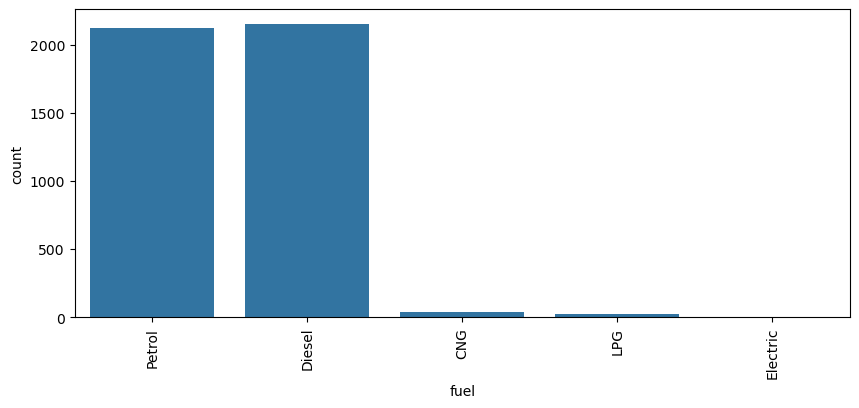

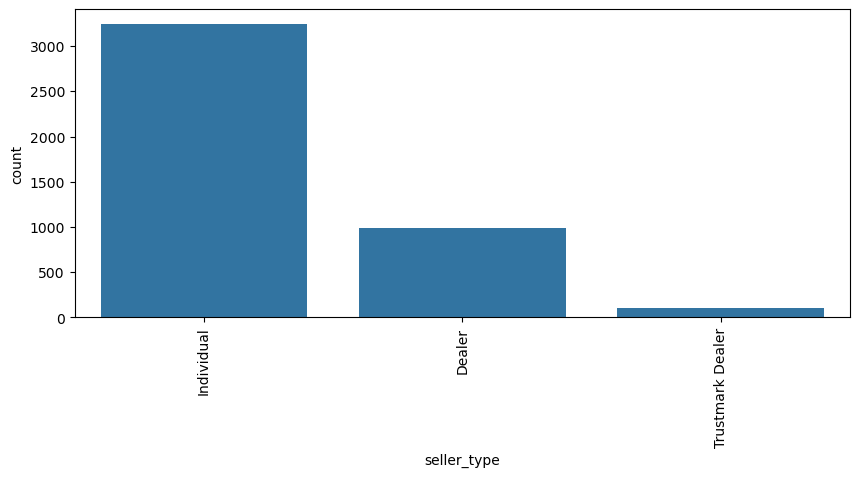

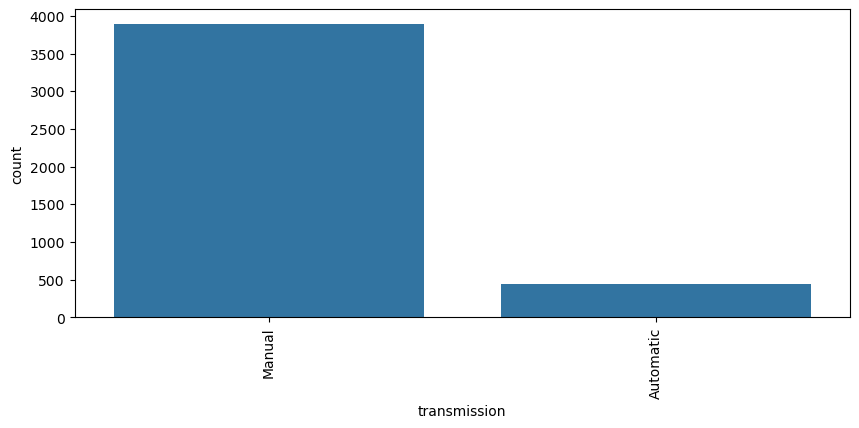

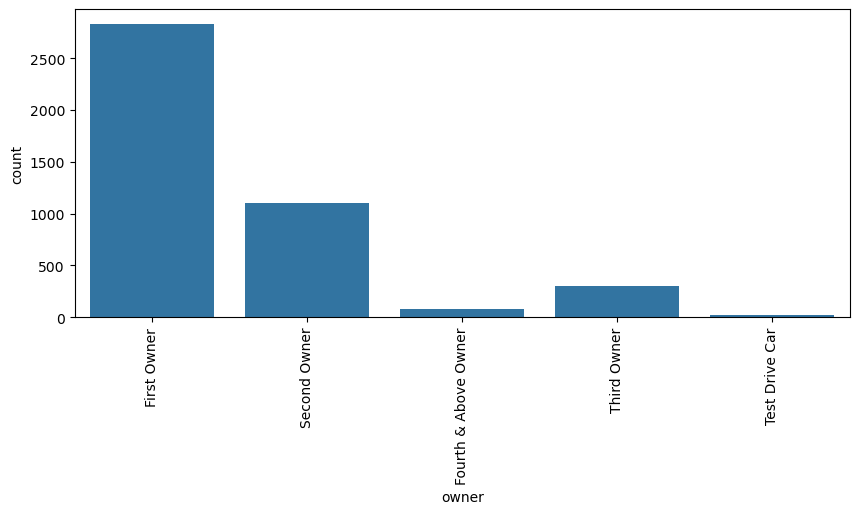

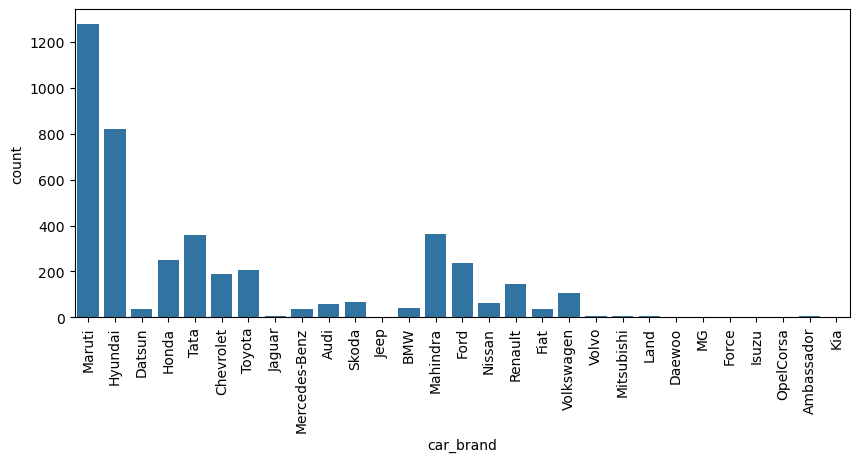

In [17]:
for i in df.select_dtypes('object').columns:
    plt.figure(figsize=(10,4))
    sns.countplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

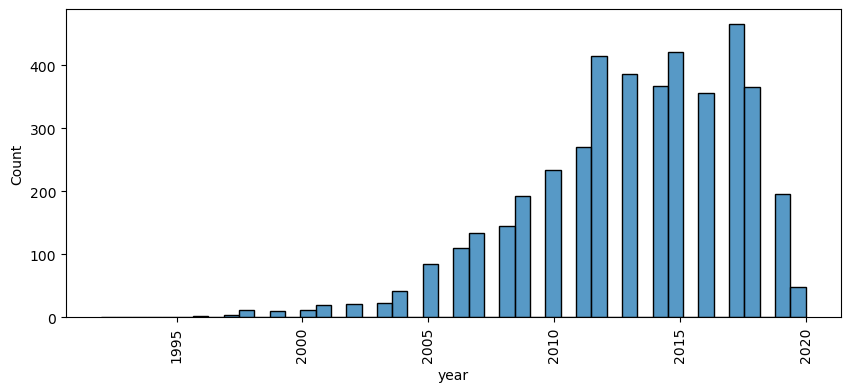

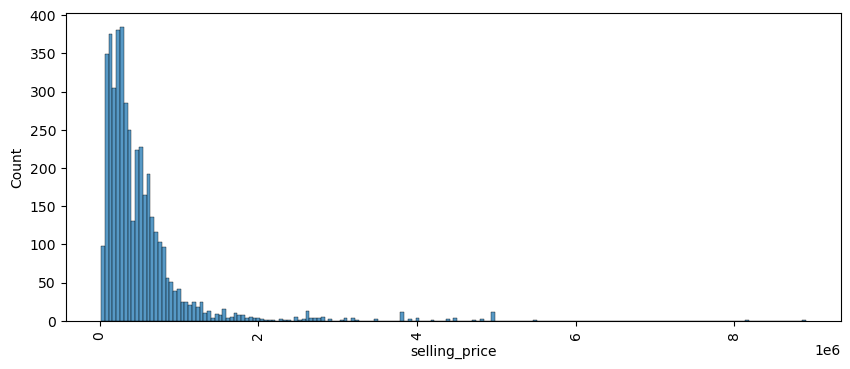

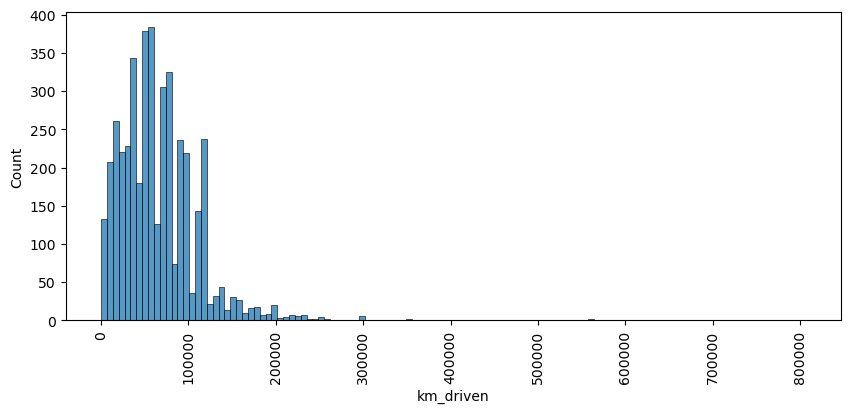

In [18]:
for i in df.select_dtypes('number').columns:
    plt.figure(figsize=(10,4))
    sns.histplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

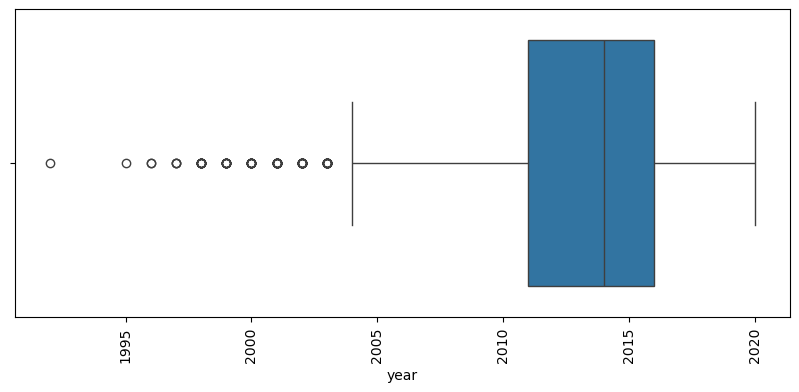

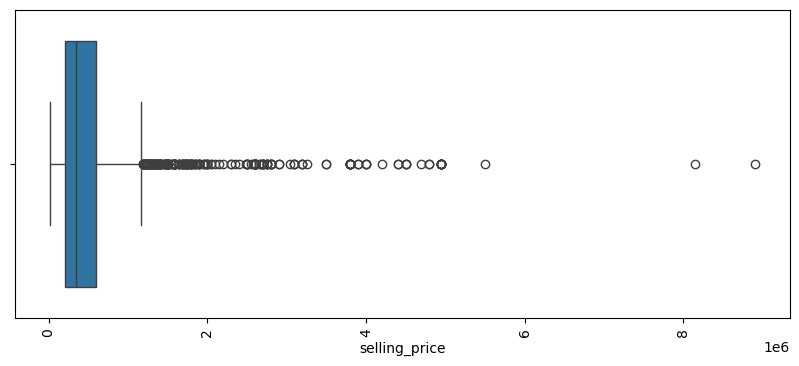

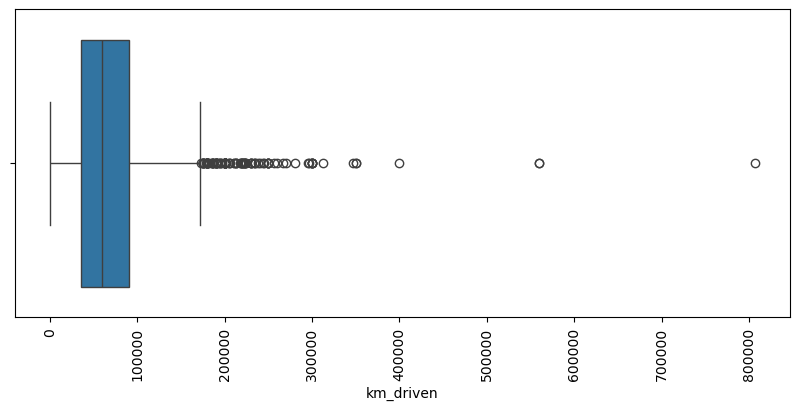

In [19]:
for i in df.select_dtypes('number').columns:
    plt.figure(figsize=(10,4))
    sns.boxplot(data=df, x=i)
    plt.xticks(rotation=90)
    plt.show()

# Bivariate

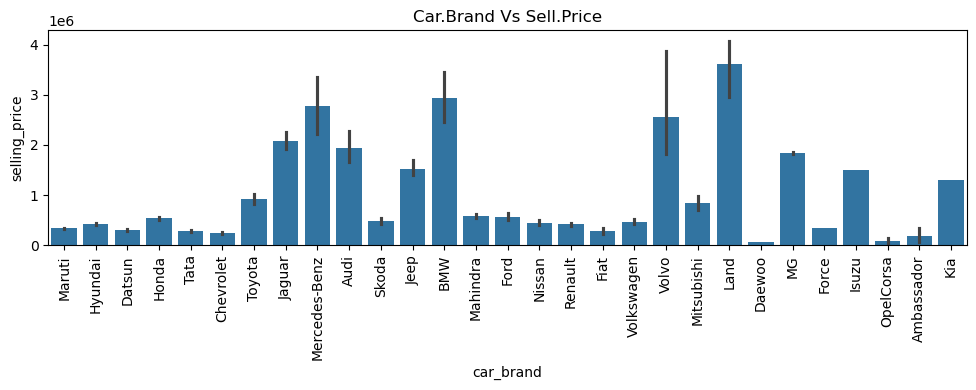

In [20]:
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='car_brand', y = 'selling_price')
plt.xticks(rotation=90)
plt.title('Car.Brand Vs Sell.Price')
plt.tight_layout()
plt.show()

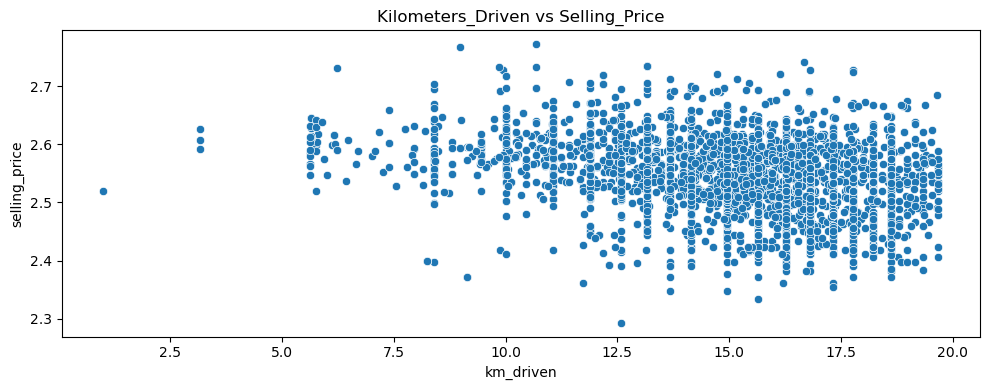

In [37]:
plt.figure(figsize=(10,4))
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.title('Kilometers_Driven vs Selling_Price')
plt.tight_layout()
plt.show()

# Multivariate

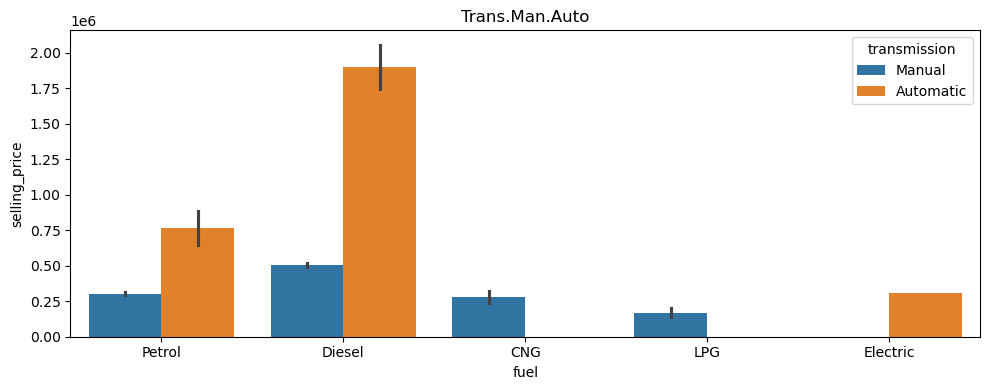

In [22]:
plt.figure(figsize=(10,4))
sns.barplot(data=df, x='fuel', y = 'selling_price', hue='transmission')
plt.title('Trans.Man.Auto')
plt.tight_layout()
plt.show()

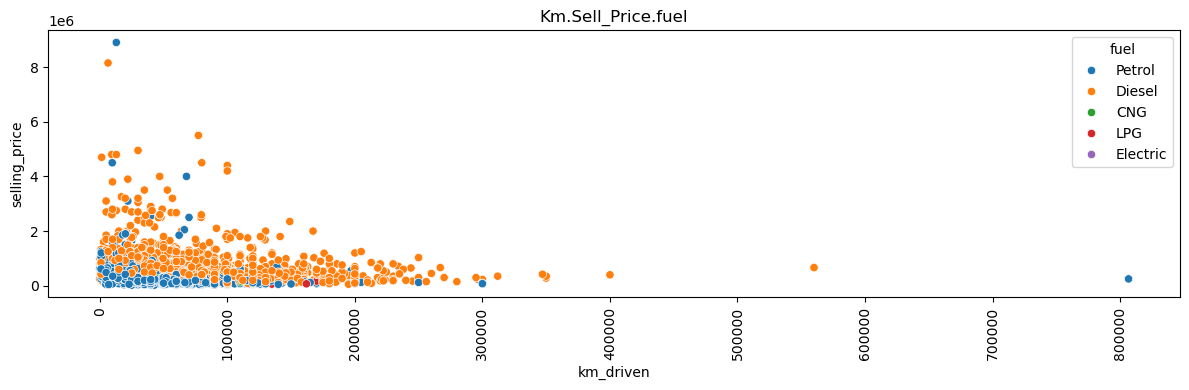

In [23]:
plt.figure(figsize=(12,4))
sns.scatterplot(data=df, x='km_driven', y = 'selling_price', hue='fuel')
plt.title('Km.Sell_Price.fuel')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Correlation Analysis

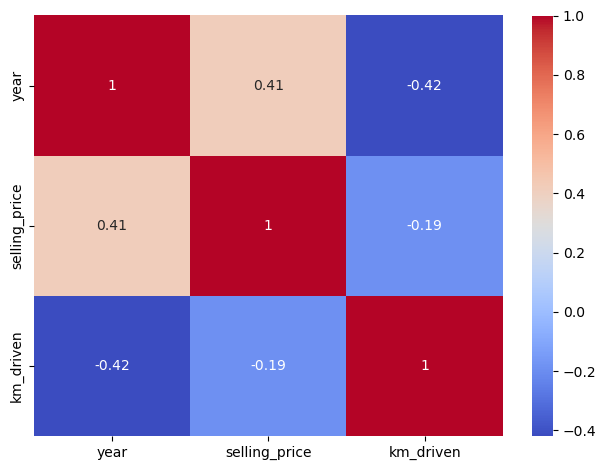

In [24]:
sns.heatmap(df.select_dtypes('number').corr(), annot=True, cmap='coolwarm')
plt.tight_layout()

# Outlier Treatment

In [26]:
df['car_age'] = 2025 - df['year']
df = df[df['km_driven'] <= df['km_driven'].quantile(0.98)]
df = df[(df['year'] >= df['year'].quantile(0.01)) & (df['year'] <= df['year'].quantile(0.99))]
df['selling_price'] = np.log(df['selling_price'])
df['km_driven'] = np.sqrt(df['km_driven'])

# One Hot Encoding

In [27]:
df = pd.get_dummies(df, columns=['fuel', 'seller_type', 'transmission', 'owner', 'car_brand'], drop_first=True)
X = df.drop(['selling_price'], axis=1)
y = df['selling_price']

# Spliting and Scaling of Data

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model

In [29]:
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)

# Adjusted R²
n = X_test.shape[0]  
p = X_test.shape[1]  
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("R² Score (Train):", lr.score(X_train, y_train))
print("R² Score (Test):", r2)
print("Adjusted R² Score:", adjusted_r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

R² Score (Train): 0.7898969356402196
R² Score (Test): 0.7901856645856531
Adjusted R² Score: 0.7791143804775602
MAE: 0.022819410705240874
MSE: 0.000845682223992221
RMSE: 0.02908061594932647


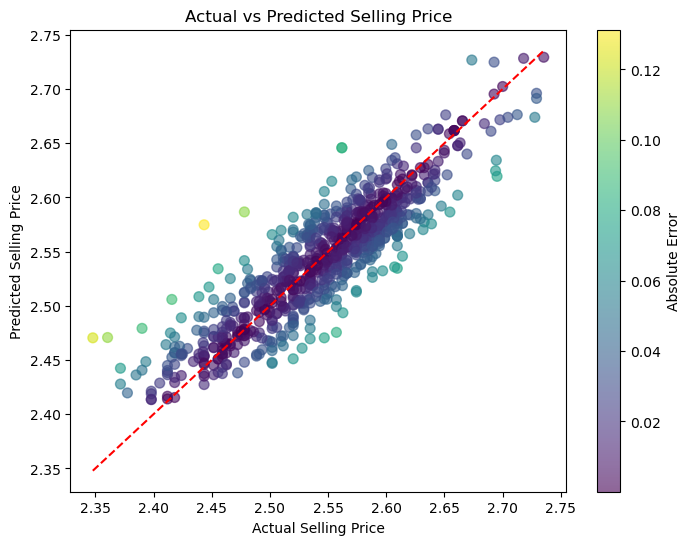

In [30]:
errors = np.abs(y_test - y_pred_lr)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr, c=errors, cmap='viridis', s=50, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.colorbar(label='Absolute Error')
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()


# Diff. between Act_Pred

In [31]:
diff = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr, 'Difference': y_test - y_pred_lr})
print(diff.head())

        Actual  Predicted  Difference
639   2.478083   2.488968   -0.010885
796   2.635857   2.613647    0.022210
2134  2.490934   2.519485   -0.028552
1056  2.539716   2.581512   -0.041796
3783  2.594114   2.567047    0.027067


# Decision Tree

In [32]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
r2_dt = r2_score(y_test, y_pred_dt)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2_dt = 1 - (1 - r2_dt) * (n - 1) / (n - p - 1)

print("Decision Tree Performance:")
print(f"R² Score: {r2_dt:.4f}")
print(f"Adjusted R²: {adjusted_r2_dt:.4f}")
print(f"MAE: {mae_dt:.4f}")
print(f"MSE: {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")

Decision Tree Performance:
R² Score: 0.7457
Adjusted R²: 0.7323
MAE: 0.0216
MSE: 0.0010
RMSE: 0.0320


# Random Forest

In [33]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
adjusted_r2_rf = 1 - (1 - r2_rf) * (n - 1) / (n - p - 1)

print("Random Forest Performance:")
print(f"R² Score: {r2_rf:.4f}")
print(f"Adjusted R²: {adjusted_r2_rf:.4f}")
print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")

Random Forest Performance:
R² Score: 0.8208
Adjusted R²: 0.8114
MAE: 0.0192
MSE: 0.0007
RMSE: 0.0269


# Support Vector Regression

In [34]:
svm = SVR()
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)
adjusted_r2_svm = 1 - (1 - r2_svm) * (n - 1) / (n - p - 1)

print("SVR Performance:")
print(f"R² Score: {r2_svm:.4f}")
print(f"Adjusted R²: {adjusted_r2_svm:.4f}")
print(f"MAE: {mae_svm:.4f}")
print(f"MSE: {mse_svm:.4f}")
print(f"RMSE: {rmse_svm:.4f}")

SVR Performance:
R² Score: 0.5892
Adjusted R²: 0.5675
MAE: 0.0324
MSE: 0.0017
RMSE: 0.0407


# K Nearest Neighbour

In [35]:
knn = KNeighborsRegressor()
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)
adjusted_r2_knn = 1 - (1 - r2_knn) * (n - 1) / (n - p - 1)
mape_knn = np.mean(np.abs((np.exp(y_test) - np.exp(y_pred_knn)) / np.exp(y_test))) * 100
rmsle_knn = np.sqrt(np.mean((np.log1p(np.exp(y_test)) - np.log1p(np.exp(y_pred_knn)))**2))

print("KNN Performance:")
print(f"R² Score: {r2_knn:.4f}")
print(f"Adjusted R²: {adjusted_r2_knn:.4f}")
print(f"MAE: {mae_knn:.4f}")
print(f"MSE: {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")

KNN Performance:
R² Score: 0.7716
Adjusted R²: 0.7595
MAE: 0.0229
MSE: 0.0009
RMSE: 0.0303


# Cross Validation

In [36]:
models = {'Linear Regression': lr, 'Decision Tree': dt, 'Random Forest': rf, 'SVR': svm, 'KNN': knn}
for name, model in models.items():
    if name in ['SVR', 'KNN']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)
    print(f"{name} Cross-Validation Score: {scores.mean():.4f}")

Linear Regression Cross-Validation Score: 0.7833
Decision Tree Cross-Validation Score: 0.6787
Random Forest Cross-Validation Score: 0.7904
SVR Cross-Validation Score: 0.5792
KNN Cross-Validation Score: 0.7703


# Final Conclusion

The Car Price Prediction project successfully demonstrates the practical application of regression models in the automotive resale domain. After performing thorough data preprocessing, exploratory data analysis, feature engineering, and model training, the following insights and results were achieved:

the performance metrics and cross-validation scores from our machine learning models :
Linear Regression Cross-Validation Score: 0.7833
Decision Tree Cross-Validation Score: 0.6787
Random Forest Cross-Validation Score: 0.7904
SVR Cross-Validation Score: 0.5792
KNN Cross-Validation Score: 0.7703
random forest is recommended for best accuracy Linear Regression for interpretability and KNN for a balance between robustness and performance while SVR should be avoided unless improved through tuning.
This project not only enhanced the understanding of various regression techniques but also highlighted the importance of data quality, feature selection, and model evaluation in real-world machine learning scenarios.